# EDA — BC5CDR Corpus
Format: JSONL (bigbio)  
KB: MeSH  
Entity types: Chemical, Disease  
Extra: Chemical-Induced-Disease (CID) relations

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('../data/raw/bc5cdr')

## 1. Parser

In [2]:
def parse_bc5cdr(filepath):
    """
    Parse BC5CDR JSONL file.
    Returns:
        docs     : list of dicts {document_id, title, abstract}
        mentions : list of dicts {document_id, entity_id, type, text, mesh_id, is_nil}
        relations: list of dicts {document_id, chemical_id, disease_id}
    """
    docs, mentions, relations = [], [], []

    with open(filepath) as f:
        for line in f:
            row = json.loads(line)
            doc_id = row['document_id']

            # extract title + abstract text
            title, abstract = '', ''
            for p in row['passages']:
                if p['type'] == 'title':
                    title = p['text'][0] if p['text'] else ''
                elif p['type'] == 'abstract':
                    abstract = p['text'][0] if p['text'] else ''
            docs.append({'document_id': doc_id, 'title': title, 'abstract': abstract})

            # extract entities
            for ent in row['entities']:
                text = ent['text'][0] if ent['text'] else ''
                norm = ent['normalized']
                is_nil = len(norm) == 0
                mesh_id = norm[0]['db_id'] if not is_nil else None
                mentions.append({
                    'document_id': doc_id,
                    'entity_id'  : ent['id'],
                    'type'       : ent['type'],
                    'text'       : text,
                    'mesh_id'    : mesh_id,
                    'is_nil'     : is_nil
                })

            # extract CID relations
            for rel in row['relations']:
                relations.append({
                    'document_id': doc_id,
                    'chemical_id': rel['arg1_id'],
                    'disease_id' : rel['arg2_id']
                })

    return docs, mentions, relations


train_docs, train_mentions, train_relations = parse_bc5cdr(DATA_DIR / 'train.jsonl')
dev_docs,   dev_mentions,   dev_relations   = parse_bc5cdr(DATA_DIR / 'validation.jsonl')
test_docs,  test_mentions,  test_relations  = parse_bc5cdr(DATA_DIR / 'test.jsonl')

train_df = pd.DataFrame(train_mentions)
dev_df   = pd.DataFrame(dev_mentions)
test_df  = pd.DataFrame(test_mentions)

print(f'Train  — docs: {len(train_docs):>4}  mentions: {len(train_df):>5}  relations: {len(train_relations):>4}')
print(f'Dev    — docs: {len(dev_docs):>4}  mentions: {len(dev_df):>5}  relations: {len(dev_relations):>4}')
print(f'Test   — docs: {len(test_docs):>4}  mentions: {len(test_df):>5}  relations: {len(test_relations):>4}')

Train  — docs:  500  mentions:  9570  relations: 15072
Dev    — docs:  500  mentions:  9773  relations: 16491
Test   — docs:  500  mentions:  9928  relations: 16250


## 2. Quick look

In [3]:
train_df.head(10)

,document_id,entity_id,type,text,mesh_id,is_nil
0,227508,3,Chemical,Naloxone,D009270,False
1,227508,4,Chemical,clonidine,D003000,False
2,227508,5,Disease,hypertensive,D006973,False
3,227508,6,Chemical,clonidine,D003000,False
4,227508,7,Chemical,nalozone,NaN,True
5,227508,8,Disease,hypotensive,D007022,False
6,227508,9,Chemical,alpha-methyldopa,D008750,False
7,227508,10,Chemical,naloxone,D009270,False
8,227508,11,Chemical,Naloxone,D009270,False
9,227508,12,Disease,hypertensive,D006973,False


## 3. Entity type distribution (Chemical vs Disease)

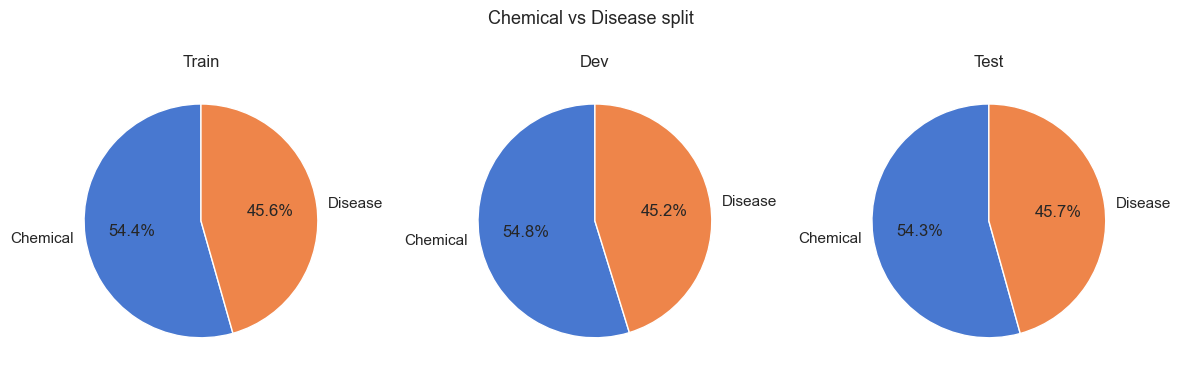

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (df, split) in zip(axes, [(train_df,'Train'),(dev_df,'Dev'),(test_df,'Test')]):
    counts = df['type'].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(split)

plt.suptitle('Chemical vs Disease split', fontsize=13)
plt.tight_layout()
plt.show()

## 4. NIL rate — mentions with no MeSH ID

In [5]:
for split, df in [('Train', train_df), ('Dev', dev_df), ('Test', test_df)]:
    nil = df['is_nil'].sum()
    print(f'{split}: {nil} NIL / {len(df)} total ({100*nil/len(df):.1f}%)')

print()
print('NIL rate by entity type (train):')
print(train_df.groupby('type')['is_nil'].mean().mul(100).round(1).rename('nil_%'))

Train: 76 NIL / 9570 total (0.8%)
Dev: 60 NIL / 9773 total (0.6%)
Test: 91 NIL / 9928 total (0.9%)

NIL rate by entity type (train):
type
Chemical    0.8
Disease     0.7
Name: nil_%, dtype: float64


## 5. Mention length distribution

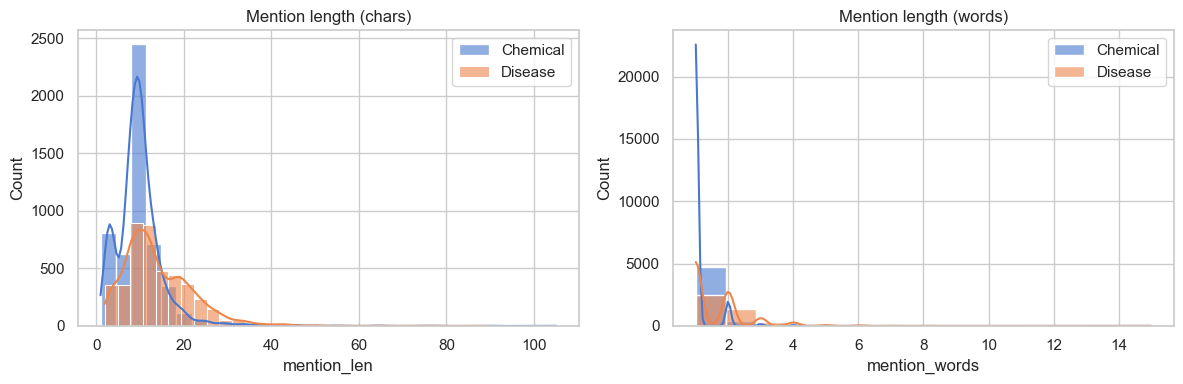

         mention_len                                           mention_words  \
               count   mean   std  min  25%   50%   75%    max         count   
type                                                                           
Chemical      5207.0   9.91  5.93  1.0  7.0   9.0  12.0  105.0        5207.0   
Disease       4363.0  14.02  8.04  2.0  8.0  12.0  19.0   89.0        4363.0   

                                                
          mean   std  min  25%  50%  75%   max  
type                                            
Chemical  1.11  0.43  1.0  1.0  1.0  1.0  15.0  
Disease   1.62  0.97  1.0  1.0  1.0  2.0  15.0  


In [6]:
train_df['mention_len']   = train_df['text'].str.len()
train_df['mention_words'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for etype, grp in train_df.groupby('type'):
    sns.histplot(grp['mention_len'], bins=30, ax=axes[0], label=etype, kde=True, alpha=0.6)
    sns.histplot(grp['mention_words'], bins=15, ax=axes[1], label=etype, kde=True, alpha=0.6)

axes[0].set_title('Mention length (chars)')
axes[1].set_title('Mention length (words)')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

print(train_df.groupby('type')[['mention_len','mention_words']].describe().round(2))

## 6. Mentions per document

Chemical: mean=10.4, max=42
Disease: mean=8.7, max=33


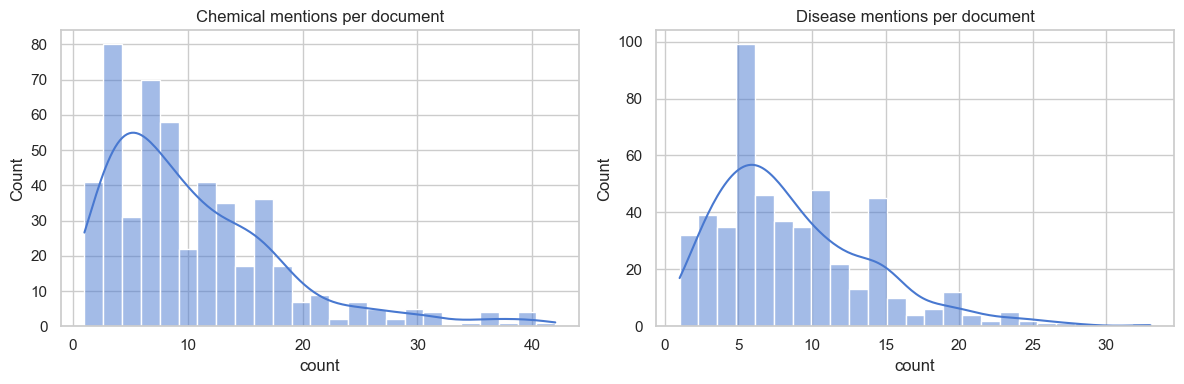

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, etype in zip(axes, ['Chemical', 'Disease']):
    counts = train_df[train_df['type']==etype].groupby('document_id').size()
    sns.histplot(counts, bins=25, ax=ax, kde=True)
    ax.set_title(f'{etype} mentions per document')
    ax.set_xlabel('count')
    print(f'{etype}: mean={counts.mean():.1f}, max={counts.max()}')

plt.tight_layout()
plt.show()

## 7. Most frequent mentions and MeSH IDs

In [8]:
for etype in ['Chemical', 'Disease']:
    sub = train_df[train_df['type']==etype]
    print(f'=== Top 10 {etype} mention texts ===')
    print(sub['text'].str.lower().value_counts().head(10).to_string())
    print()
    print(f'=== Top 10 {etype} MeSH IDs ===')
    print(sub[~sub['is_nil']]['mesh_id'].value_counts().head(10).to_string())
    print()

=== Top 10 Chemical mention texts ===
text
cocaine        108
dopamine        63
nicotine        58
morphine        53
lithium         49
haloperidol     46
warfarin        42
clonidine       40
cisplatin       38
lidocaine       36

=== Top 10 Chemical MeSH IDs ===
mesh_id
D003042    108
D004317     78
D016559     69
D004298     68
D020123     64
D009538     58
D008094     57
D009020     53
D012964     50
D006220     46

=== Top 10 Disease mention texts ===
text
pain                     89
toxicity                 78
proteinuria              66
hypotension              61
seizures                 61
hypertension             55
seizure                  44
hepatitis                39
myocardial infarction    32
bradycardia              27

=== Top 10 Disease MeSH IDs ===
mesh_id
D012640    131
D007674    102
D064420     92
D007022     90
D010146     89
D006973     82
D056486     82
D011507     67
D004409     50
D009369     44



## 8. Unique MeSH IDs and zero-shot analysis

In [9]:
for etype in ['Chemical', 'Disease']:
    train_ids = set(train_df[(train_df['type']==etype) & (~train_df['is_nil'])]['mesh_id'])
    test_ids  = set(test_df[(test_df['type']==etype)   & (~test_df['is_nil'])]['mesh_id'])
    unseen    = test_ids - train_ids
    print(f'{etype}:')
    print(f'  unique MeSH IDs in train : {len(train_ids)}')
    print(f'  unique MeSH IDs in test  : {len(test_ids)}')
    print(f'  zero-shot IDs (test only): {len(unseen)} ({100*len(unseen)/len(test_ids):.1f}%)')
    print()

Chemical:
  unique MeSH IDs in train : 663
  unique MeSH IDs in test  : 670
  zero-shot IDs (test only): 368 (54.9%)

Disease:
  unique MeSH IDs in train : 664
  unique MeSH IDs in test  : 645
  zero-shot IDs (test only): 250 (38.8%)



## 9. Surface form variation per MeSH ID

Chemical: mean=1.49, max=6
Disease: mean=2.19, max=27


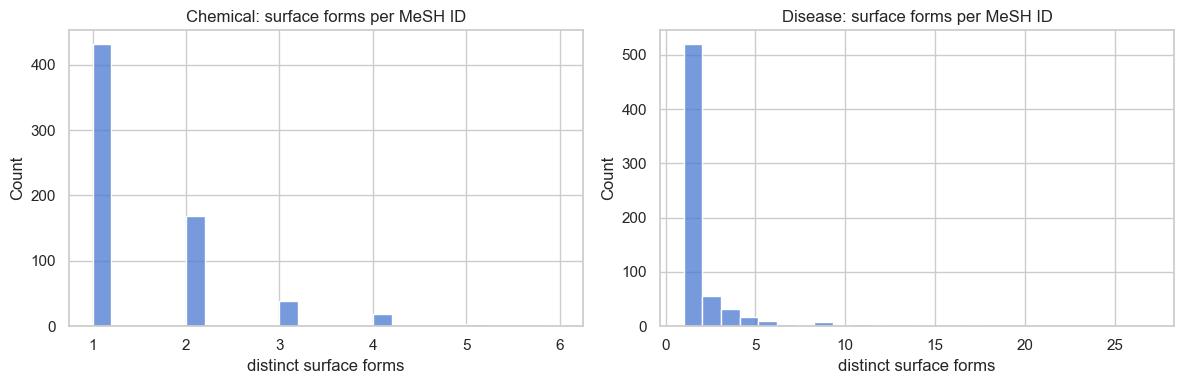

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, etype in zip(axes, ['Chemical', 'Disease']):
    sub = train_df[(train_df['type']==etype) & (~train_df['is_nil'])]
    mesh_to_surfaces = {}
    for _, row in sub.iterrows():
        mesh_to_surfaces.setdefault(row['mesh_id'], set()).add(row['text'].lower())
    surface_counts = pd.Series({k: len(v) for k, v in mesh_to_surfaces.items()})
    sns.histplot(surface_counts, bins=25, ax=ax)
    ax.set_title(f'{etype}: surface forms per MeSH ID')
    ax.set_xlabel('distinct surface forms')
    print(f'{etype}: mean={surface_counts.mean():.2f}, max={surface_counts.max()}')

plt.tight_layout()
plt.show()

## 10. CID relations — Chemical-Induced-Disease

In [11]:
print(f'Train CID relations: {len(train_relations)}')
print(f'Dev   CID relations: {len(dev_relations)}')
print(f'Test  CID relations: {len(test_relations)}')
print()
print('Avg relations per document (train):', round(len(train_relations)/len(train_docs), 2))

# docs with most relations
rel_df = pd.DataFrame(train_relations)
top_docs = rel_df.groupby('document_id').size().sort_values(ascending=False).head(5)
print()
print('Top 5 docs by CID relation count:')
print(top_docs)

Train CID relations: 15072
Dev   CID relations: 16491
Test  CID relations: 16250

Avg relations per document (train): 30.14

Top 5 docs by CID relation count:
document_id
10669626    288
12639165    280
10704919    280
1592014     240
2440413     210
dtype: int64


## 11. Comparison with NCBI Disease

In [12]:
bc5cdr_disease = train_df[train_df['type']=='Disease']
bc5cdr_chem    = train_df[train_df['type']=='Chemical']

summary = pd.DataFrame({
    'dataset'        : ['BC5CDR-d (train)', 'BC5CDR-c (train)'],
    'mentions'       : [len(bc5cdr_disease), len(bc5cdr_chem)],
    'unique_mesh'    : [
        bc5cdr_disease[~bc5cdr_disease['is_nil']]['mesh_id'].nunique(),
        bc5cdr_chem[~bc5cdr_chem['is_nil']]['mesh_id'].nunique()
    ],
    'nil_%'          : [
        round(100*bc5cdr_disease['is_nil'].mean(), 1),
        round(100*bc5cdr_chem['is_nil'].mean(), 1)
    ],
    'avg_mention_len': [
        round(bc5cdr_disease['text'].str.len().mean(), 1),
        round(bc5cdr_chem['text'].str.len().mean(), 1)
    ]
})

summary.set_index('dataset')

,mentions,unique_mesh,nil_%,avg_mention_len
dataset,,,,
BC5CDR-d (train),4363,664,0.7,14.0
BC5CDR-c (train),5207,663,0.8,9.9
